# Maternal mortality from the 2024 Nigeria VASA: a DHS-style calculation

This notebook re-derives the maternal mortality ratio (MMR) that the 2024 Nigeria Verbal
and Social Autopsy (NVASA) report publishes in its Chapter 7, then extends it:

1. **Household-death method (the report's method).** Deaths of women aged 15–49 listed in
   the 2024 NDHS household death roster and given a physician-certified cause by verbal
   autopsy, divided by woman-years of exposure built from the NDHS household roster, and
   converted to a ratio per live birth with the general fertility rate (GFR) from the NDHS
   birth histories.
2. **Both VASA sample frames.** The VASA file also holds deaths from extra *screened*
   households. Those have no exposure denominators, so for that frame the MMR is derived
   indirectly from the proportion of deaths that are maternal.
3. **Causes of maternal death**, by frame.
4. **Sibling-survival method.** The 2024 NDHS women's questionnaire also carried the
   sibling history module, so the classic DHS sisterhood estimate can be computed from the
   same survey and set beside the household-death estimate.
5. **Comparison** with the DHS-published series and with the GBD and MMEIG modelled series.

All inputs are read from IHME's J: drive (`DHS_PROG_VASA/NGA/2024` and
`DHS_PROG_DHS/NGA/2023_2024`) and never modified. Tables of counts pass through
`nga_vasa.redact` (unweighted cells below 5 are masked or pooled).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nga_vasa as nv
import mmr
from nga_vasa import redact, redact_crosstab

pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 30)
AGE = mmr.AGE_LABELS

## 1. Deaths of women from the VASA file

`vicdmm` is the physician-assigned maternal category. Following the report, a *maternal*
death is any `vicdmm` category except "late maternal" (43 days to 1 year). A
*pregnancy-related* death is defined by timing alone: pregnant at death, died during
delivery, within 24 hours or within 6 weeks of delivery, or within 6 weeks of an abortion
or miscarriage.

In [2]:
df, meta = nv.load()
lab = nv.Labels(meta)
ad = nv.adults(df)
deaths = pd.DataFrame({
    "cluster": pd.to_numeric(ad.vaclust, errors="coerce"),
    "age_at_death": pd.to_numeric(ad.vadagen, errors="coerce"),
    "months_since_death": pd.to_numeric(ad.vndhsc, errors="coerce") - pd.to_numeric(ad.va1606c, errors="coerce"),
    "va005w": pd.to_numeric(ad.va005, errors="coerce") / 1e6,   # NDHS household weight (NDHS frame only)
    "vaw": nv.weights(ad),                                       # VASA weight (all deaths)
    "nsamp": ad.nsamp,
    "frame": ad.nsamp.map({1: "NDHS households", 2: "Screened households"}),
    "vicdmm": pd.to_numeric(ad.vicdmm, errors="coerce"),
    "vicd": ad.vicd.astype(str),
    "zone": lab.decode(ad, "va1201a"),
    "residence": lab.decode(ad, "va1201e"),
})
deaths["maternal"] = deaths.vicdmm.notna() & (deaths.vicdmm != 7)
deaths["late_maternal"] = deaths.vicdmm == 7
deaths["preg_related"] = ((ad.a4167 == 1) | (ad.a4168_1 == 1) | (ad.a4168_3 == 1) | (ad.a4168 == 1) | (ad.a4194 == 1)).to_numpy()
deaths["in_window"] = deaths.months_since_death.between(0, 59) & deaths.age_at_death.between(15, 49)
win = deaths[deaths.in_window].copy()
win["age_group"] = (np.floor(win.age_at_death / 5) * 5).astype(int)
print("women's deaths 15-49 within 5 years of the NDHS interview, by frame:")
display(redact_crosstab(pd.crosstab(win.frame, win.maternal.map({True: "maternal", False: "not maternal"}))))

women's deaths 15-49 within 5 years of the NDHS interview, by frame:


maternal,maternal,not maternal
frame,,
NDHS households,157,450
Screened households,398,929


## 2. Exposure: woman-years from the NDHS household roster

De jure women in the NDHS household file contribute time at ages 15–49 over the 60 months
before the interview; the deceased women contribute time up to the month of death. The
result reproduces the report's Table 7.1 exposure to within 0.1%.

In [3]:
f1 = deaths[deaths.nsamp == 1]
E_live = mmr.living_women_exposure()
E_dead = mmr.deceased_women_exposure(f1, "va005w")
E = E_live.add(E_dead, fill_value=0)
table71 = pd.Series([39273, 36283, 32065, 27341, 23378, 17169, 15857], index=mmr.AGE_GROUPS)
exp_cmp = pd.DataFrame({"living women": E_live.sum().round(0), "deceased women": E_dead.sum().round(0),
                        "total": E.sum().round(0), "report Table 7.1": table71})
exp_cmp.index = AGE
exp_cmp.loc["Total"] = exp_cmp.sum()
exp_cmp.astype(int)

,living women,deceased women,total,report Table 7.1
15-19,38968,317,39285,39273
20-24,35957,309,36266,36283
25-29,31808,255,32063,32065
30-34,27155,180,27336,27341
35-39,23120,268,23388,23378
40-44,16933,233,17166,17169
45-49,15669,212,15881,15857
Total,189610,1774,191385,191366


## 3. Fertility: GFR from the NDHS birth histories

Births in the 60 months before interview by mother's age at birth, over woman-years of
interviewed women. The rate is standardised to the age distribution of respondents, as the
report does for every rate. The report gives GFR 159.3 and TFR 5.1.

In [4]:
ir = mmr.read_ir(sibling=True)
births, fexp, std = mmr.fertility(ir, 60)
asfr = (births.sum() / fexp.sum() * 1000)
fert = pd.DataFrame({"ASFR per 1,000": asfr.round(1), "standard age weight": std.round(3)})
fert.index = AGE
display(fert)
print(f"GFR (standardised) = {mmr.standardised_rate(births.sum(), fexp.sum(), std) * 1000:.1f} per 1,000 women 15-49  (report 159.3)")
print(f"TFR = {(births.sum() / fexp.sum()).sum() * 5:.2f}  (report 5.1)")

,"ASFR per 1,000",standard age weight
15-19,87.8,0.208
20-24,220.9,0.175
25-29,247.8,0.165
30-34,218.0,0.143
35-39,147.0,0.125
40-44,77.2,0.105
45-49,27.0,0.078


GFR (standardised) = 157.7 per 1,000 women 15-49  (report 159.3)
TFR = 5.13  (report 5.1)


## 4. Frame 1 (NDHS households): direct MMR, the report's method

Rates are deaths per 1,000 woman-years by age group, standardised to the respondent age
distribution. MMR = standardised maternal rate / standardised GFR × 100,000. Confidence
intervals are leave-one-cluster-out jackknife over the 1,380 NDHS clusters.

In [5]:
inwin = f1.in_window
D = {"all": mmr.deaths_table(f1, inwin, "va005w"),
     "maternal": mmr.deaths_table(f1, inwin & f1.maternal, "va005w"),
     "preg_related": mmr.deaths_table(f1, inwin & f1.preg_related, "va005w")}
by_age = pd.DataFrame({
    "all deaths (wtd)": D["all"].sum().round(0),
    "maternal deaths (wtd)": D["maternal"].sum().round(0),
    "exposure years": E.sum().round(0),
    "all-cause rate /1,000": (D["all"].sum() / E.sum() * 1000).round(2),
    "maternal rate /1,000": (D["maternal"].sum() / E.sum() * 1000).round(2),
    "% of deaths maternal": (D["maternal"].sum() / D["all"].sum() * 100).round(1),
})
by_age.index = AGE
display(by_age)
print("report Table 7.3 maternal rates: 0.80, 0.92, 1.11, 0.95, 0.98, 1.00, 0.42; Table 7.1 all-cause: 1.93, 3.33, 2.63, 2.88, 3.60, 5.56, 5.74")

,all deaths (wtd),maternal deaths (wtd),exposure years,"all-cause rate /1,000","maternal rate /1,000",% of deaths maternal
15-19,81.0,32.0,39285.0,2.05,0.82,40.1
20-24,121.0,33.0,36266.0,3.33,0.92,27.6
25-29,83.0,34.0,32063.0,2.60,1.05,40.3
30-34,79.0,26.0,27336.0,2.91,0.95,32.6
35-39,83.0,23.0,23388.0,3.55,0.98,27.7
40-44,99.0,18.0,17166.0,5.76,1.06,18.4
45-49,90.0,7.0,15881.0,5.70,0.42,7.3


report Table 7.3 maternal rates: 0.80, 0.92, 1.11, 0.95, 0.98, 1.00, 0.42; Table 7.1 all-cause: 1.93, 3.33, 2.63, 2.88, 3.60, 5.56, 5.74


In [6]:
est1 = mmr.estimate(D, E, births, fexp, std)
jk1 = mmr.jackknife(D, E, births, fexp, std, keys=("maternal", "preg_related", "all"))
direct = pd.DataFrame({
    "this notebook": [est1.maternal_rate_per_1000, est1.maternal_ratio_per_100000, est1.preg_related_rate_per_1000,
                      est1.preg_related_ratio_per_100000, est1.all_rate_per_1000, est1.gfr_per_1000],
    "95% CI": [None, f"{jk1.loc['maternal','lower']:.0f}-{jk1.loc['maternal','upper']:.0f}", None,
               f"{jk1.loc['preg_related','lower']:.0f}-{jk1.loc['preg_related','upper']:.0f}", None, None],
    "NVASA report": [0.91, 572, 0.93, 583, 3.29, 159.3],
    "report 95% CI": [None, "475-688", None, "485-700", None, None],
}, index=["maternal mortality rate /1,000", "MMR /100,000 live births", "pregnancy-related rate /1,000",
          "PRMR /100,000 live births", "all-cause female mortality 15-49 /1,000", "GFR /1,000"])
direct["this notebook"] = direct["this notebook"].astype(float).round(2)
direct

,this notebook,95% CI,NVASA report,report 95% CI
"maternal mortality rate /1,000",0.91,NaN,0.91,NaN
"MMR /100,000 live births",575.82,469-683,572.00,475-688
"pregnancy-related rate /1,000",0.91,NaN,0.93,NaN
"PRMR /100,000 live births",579.98,472-688,583.00,485-700
"all-cause female mortality 15-49 /1,000",3.35,NaN,3.29,NaN
"GFR /1,000",157.73,NaN,159.30,NaN


The household-death method reproduces the published numbers: 173 weighted maternal deaths,
a maternal mortality rate of 0.91 per 1,000, and an MMR within one percent of 572. The
small differences come from the GFR standardisation and from weighting (the report uses
the NDHS household weight; the VASA weight gives 573).

## 5. Frame 2 (screened households) and both frames together

The screened households were added to find more deaths of women, but the report did not
use them for rates because (a) no births were collected there, so there is no
denominator, and (b) "internal evidence suggests that the deaths reported in the
additional households referred to some larger population" (Section 7.1.1).

What the screened frame *can* contribute is a second, larger estimate of the proportion of
women's deaths that are maternal (PMDF). Applying each frame's age-specific PMDF to the
frame-1 all-cause rates gives an indirect MMR, the same logic WHO uses to convert PMDF to
MMR.

In [7]:
def pmdf_table(d, w="vaw"):
    g = d.groupby("age_group")
    return pd.Series({
        "deaths (unweighted)": len(d),
        "maternal deaths (unweighted)": int(d.maternal.sum()),
        "PMDF % (weighted)": 100 * d[w][d.maternal].sum() / d[w].sum(),
        "pregnancy-related % (weighted)": 100 * d[w][d.preg_related].sum() / d[w].sum(),
    })
frames = {"NDHS households": win[win.nsamp == 1], "Screened households": win[win.nsamp == 2], "Both frames": win}
display(pd.DataFrame({k: pmdf_table(v) for k, v in frames.items()}).round(1))

# age-specific PMDF by frame
pm = win.groupby(["age_group", "frame"]).apply(lambda d: 100 * d.vaw[d.maternal].sum() / d.vaw.sum()).unstack()
pm["Both frames"] = win.groupby("age_group").apply(lambda d: 100 * d.vaw[d.maternal].sum() / d.vaw.sum())
pm.index = AGE
display(pm.round(1))

,NDHS households,Screened households,Both frames
deaths (unweighted),607.0,1327.0,1934.0
maternal deaths (unweighted),157.0,398.0,555.0
PMDF % (weighted),27.3,30.1,29.2
pregnancy-related % (weighted),27.5,30.3,29.4


frame,NDHS households,Screened households,Both frames
15-19,40.5,27.4,32.1
20-24,28.3,39.6,35.0
25-29,40.5,44.1,43.0
30-34,32.1,40.7,38.2
35-39,27.4,36.3,33.7
40-44,18.3,15.8,16.7
45-49,7.5,4.8,5.6


In [8]:
# Indirect MMR: sum over ages of std weight x PMDF_a x all-cause rate_a (frame 1), over standardised GFR
all_rate = D["all"].sum() / E.sum()            # frame-1 all-cause rates by age (per woman-year)
gfr = mmr.standardised_rate(births.sum(), fexp.sum(), std)
indirect = {}
for k, d in frames.items():
    pmdf_a = d.groupby("age_group").apply(lambda x: x.vaw[x.maternal].sum() / x.vaw.sum()).reindex(mmr.AGE_GROUPS)
    indirect[k] = (std * pmdf_a.to_numpy() * all_rate.to_numpy()).sum() / gfr * 1e5
indirect = pd.Series(indirect, name="indirect MMR /100,000 (frame PMDF x frame-1 all-cause rates)").round(0)
indirect.to_frame()

,"indirect MMR /100,000 (frame PMDF x frame-1 all-cause rates)"
NDHS households,578.0
Screened households,625.0
Both frames,609.0


The screened frame's maternal share is about three points higher than the NDHS frame's
(30% vs 27%), which moves the indirect MMR up by roughly 60 per 100,000. Given the
report's caution about the screened households, the frame-1 direct estimate remains the
defensible headline; the screened frame's main value is the larger cause-of-death sample.

## 6. Causes of maternal death, by frame

`vicdmm` groups the ICD-11 maternal codes into the WHO ICD-MM categories. Percentages are
weighted; unweighted counts under 5 are masked.

In [9]:
mat = win[win.maternal].copy()
mat["cause"] = lab.decode(mat, "vicdmm").str.replace("Direct_", "Direct: ").str.replace("Indirect_", "Indirect: ").str.replace("Unspecified_", "")
ct_w = mat.groupby(["cause", "frame"]).vaw.sum().unstack(fill_value=0)
ct_w["Both frames"] = ct_w.sum(axis=1)
pct = (ct_w / ct_w.sum() * 100).round(1)
pct.columns = [f"{c} %" for c in pct.columns]
ct_n = mat.groupby(["cause", "frame"]).size().unstack(fill_value=0)
ct_n.columns = [f"{c} n" for c in ct_n.columns]
cause_tab = pd.concat([pct, ct_n], axis=1).sort_values("Both frames %", ascending=False)
display(redact(cause_tab, count_cols=list(ct_n.columns)))
print("report Table 7.6 (15-49): haemorrhage 37.6, unspecified 16.1, abortion 15.1, indirect 13.6, hypertensive 11.2, infection 6.0, other 0.4")

,NDHS households %,Screened households %,Both frames %,NDHS households n,Screened households n
cause,,,,,
Direct: Obstetric haemorrhage,38.2,36.7,37.2,58,149
Indirect: Non-obstetric complications,13.7,17.3,16.2,22,63
Unknown/undetermined,15.6,15.6,15.6,27,64
"Direct: Hypertensive disorders in pregnancy, childbirth and the puerperium",10.8,15.0,13.7,14,49
Direct: Pregnancies with abortive outcome,14.9,7.7,10.0,24,39
Direct: Pregnancy-related infection,6.3,6.7,6.6,11,29
Direct: Other obstetric complications,-,-,-,<5,5


report Table 7.6 (15-49): haemorrhage 37.6, unspecified 16.1, abortion 15.1, indirect 13.6, hypertensive 11.2, infection 6.0, other 0.4


In [10]:
grp = mat.vicdmm.map(lambda x: "Direct" if x in (1, 2, 3, 4, 5) else ("Indirect" if x == 6 else "Unspecified"))
t = mat.groupby([grp.rename("type"), "frame"]).vaw.sum().unstack()
t["Both frames"] = t.sum(axis=1)
display((t / t.sum() * 100).round(1))
print("report Table 7.5: direct 70.3, indirect 13.6, unspecified 16.1")
print("late maternal deaths (43 days-1 year), both frames, unweighted:", int(win.late_maternal.sum()))

frame,NDHS households,Screened households,Both frames
type,,,
Direct,70.7,67.1,68.2
Indirect,13.7,17.3,16.2
Unspecified,15.6,15.6,15.6


report Table 7.5: direct 70.3, indirect 13.6, unspecified 16.1
late maternal deaths (43 days-1 year), both frames, unweighted: 22


In [11]:
# Most common ICD-11 codes among maternal deaths, both frames (small cells pooled)
icd_names = {"JA43": "Postpartum haemorrhage", "JA43.Z": "Postpartum haemorrhage, unspecified", "JB60": "Obstetric death of unspecified cause",
             "JA00": "Abortion", "JA24": "Eclampsia", "JB40": "Puerperal sepsis", "JA41": "Antepartum haemorrhage",
             "JB63.Z": "Other specified diseases complicating pregnancy", "JA25": "Pre-eclampsia", "JB63.Y": "Other diseases complicating pregnancy",
             "JB64.0": "Maternal infectious disease complicating pregnancy", "JB63.6": "Anaemia complicating pregnancy", "JA42": "Intrapartum haemorrhage"}
top = redact(mat.vicd.value_counts())
top = top.rename(index=lambda c: f"{c} {icd_names.get(c, '')}".strip()).rename("maternal deaths (unweighted)").to_frame()
top

,maternal deaths (unweighted)
vicd,
JA43 Postpartum haemorrhage,125
JB60 Obstetric death of unspecified cause,79
JA00 Abortion,49
"JA43.Z Postpartum haemorrhage, unspecified",39
JA24 Eclampsia,30
JB40 Puerperal sepsis,28
JA41 Antepartum haemorrhage,28
JB63.Z Other specified diseases complicating pregnancy,21
JA25 Pre-eclampsia,19


## 7. Sibling-survival (sisterhood) method from the same 2024 NDHS

Every woman interviewed in the 2024 NDHS listed her siblings with survival status, dates of
birth and death, and, for sisters who died, whether the death was during pregnancy,
delivery, or within two months after. This is the module DHS used for the 2008, 2013 and
2018 Nigeria estimates. The 2024 NDHS final report (FR395) carries the module in its
questionnaire but publishes no estimate from it.

DHS convention is a 7-year reference period. Three numerators are shown:

- **pregnancy-related** (DHS PRMR): died while pregnant, during delivery, or within two
  months after (`mm9` codes 2–6)
- **42-day variant**: drops deaths 43–60 days after delivery (code 6)
- **pregnancy-related excluding violence/accidents** (`mm16`)
- **maternal, NDHS 2018 definition**: within 42 days *and* not due to violence or
  accidents. This is the definition behind the published 2018 MMR of 512 (see the
  validation below).

In [12]:
sib = {}
for winm in (84, 60):
    Es, Ds, dd = mmr.sibling_tables(ir, winm)
    bs, fs, stds = mmr.fertility(ir, winm)
    est = mmr.estimate(Ds, Es, bs, fs, stds)
    jk = mmr.jackknife(Ds, Es, bs, fs, stds, keys=("preg_related", "preg_42d", "maternal_excl_ext", "maternal_42d_excl_ext", "all"))
    sib[winm] = dict(E=Es, D=Ds, deaths=dd, births=bs, fexp=fs, std=stds, est=est, jk=jk)
    print(f"window {winm} months: sister-years {Es.sum().sum():,.0f}; sister deaths 15-49 (unweighted) {len(dd)}; "
          f"pregnancy-related {int(dd.preg_related.sum())}; GFR {est.gfr_per_1000:.1f}; TFR {est.tfr:.2f}")

rows = []
for winm, s in sib.items():
    for key, label in [("preg_related", "PRMR (2-month window)"), ("preg_42d", "PRMR (42-day window)"),
                       ("maternal_excl_ext", "pregnancy-related excl. violence/accidents"),
                       ("maternal_42d_excl_ext", "maternal, NDHS 2018 definition (42 days, excl. violence/accidents)")]:
        r = s["jk"].loc[key]
        rows.append({"window": f"{winm // 12} years", "measure": label, "ratio per 100,000": round(r.estimate),
                     "95% CI": f"{r.lower:.0f}-{r.upper:.0f}", "rate per 1,000": round(s["est"][f"{key}_rate_per_1000"], 2)})
    rows.append({"window": f"{winm // 12} years", "measure": "all-cause female mortality 15-49", "ratio per 100,000": None,
                 "95% CI": None, "rate per 1,000": round(s["est"].all_rate_per_1000, 2)})
pd.DataFrame(rows).set_index(["window", "measure"])

window 84 months: sister-years 439,896; sister deaths 15-49 (unweighted) 973; pregnancy-related 292; GFR 162.9; TFR 5.30


window 60 months: sister-years 323,752; sister deaths 15-49 (unweighted) 669; pregnancy-related 185; GFR 157.7; TFR 5.13


ratio per 100,000   95% CI  rate per 1,000
window  measure                                                                                       
7 years PRMR (2-month window)                                           420.0  355-486            0.68
        PRMR (42-day window)                                            396.0  333-460            0.65
        pregnancy-related excl. violence/accidents                      391.0  329-453            0.64
        maternal, NDHS 2018 definition (42 days, excl. ...              369.0  308-430            0.60
        all-cause female mortality 15-49                                  NaN      NaN            2.40
5 years PRMR (2-month window)                                           376.0  302-450            0.59
        PRMR (42-day window)                                            357.0  284-430            0.56
        pregnancy-related excl. violence/accidents                      343.0  273-413            0.54
        maternal, NDHS 2018 definition (42 days, excl. ...              327.0  259-396            0.52
        all-cause female mortality 15-49                                  NaN      NaN            2.30

### Household-death vs sibling estimates, age by age

Both come from the same 2024 NDHS households and respondents, over the same five years.

In [13]:
s5 = sib[60]
cmp = pd.DataFrame({
    "household: all-cause /1,000": (D["all"].sum() / E.sum() * 1000).round(2),
    "sibling: all-cause /1,000": (s5["D"]["all"].sum() / s5["E"].sum() * 1000).round(2),
    "household: pregnancy-related /1,000": (D["preg_related"].sum() / E.sum() * 1000).round(2),
    "sibling: pregnancy-related /1,000": (s5["D"]["preg_related"].sum() / s5["E"].sum() * 1000).round(2),
    "household deaths (unweighted)": win[win.nsamp == 1].groupby("age_group").size().reindex(mmr.AGE_GROUPS).to_numpy(),
    "sister deaths (unweighted)": s5["deaths"].assign(g=lambda d: (np.floor(d.age_at_death / 5) * 5).astype(int)).groupby("g").size().reindex(mmr.AGE_GROUPS).to_numpy(),
})
cmp.index = AGE
cmp["sibling / household (all-cause)"] = (cmp["sibling: all-cause /1,000"] / cmp["household: all-cause /1,000"]).round(2)
display(cmp)
print(f"standardised all-cause 15-49: household {est1.all_rate_per_1000:.2f}, sibling (5 yr) {s5['est'].all_rate_per_1000:.2f}, "
      f"sibling (7 yr) {sib[84]['est'].all_rate_per_1000:.2f} per 1,000; NDHS 2018 sibling (7 yr): 3.18")

,"household: all-cause /1,000","sibling: all-cause /1,000","household: pregnancy-related /1,000","sibling: pregnancy-related /1,000",household deaths (unweighted),sister deaths (unweighted),sibling / household (all-cause)
15-19,2.05,1.58,0.88,0.27,75,73,0.77
20-24,3.33,1.93,0.95,0.69,95,98,0.58
25-29,2.60,2.09,1.05,0.66,84,113,0.80
30-34,2.91,2.25,0.93,0.89,82,114,0.77
35-39,3.55,2.95,0.99,0.77,84,122,0.83
40-44,5.76,2.76,0.99,0.66,87,84,0.48
45-49,5.70,3.87,0.39,0.20,100,65,0.68


standardised all-cause 15-49: household 3.35, sibling (5 yr) 2.30, sibling (7 yr) 2.40 per 1,000; NDHS 2018 sibling (7 yr): 3.18


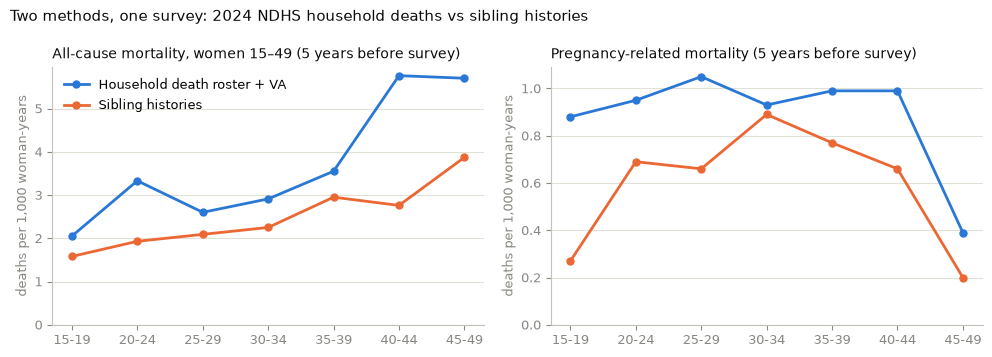

In [14]:
BLUE, ORANGE, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#898781", "#e1e0d9"
def tidy(ax):
    for s in ["top", "right"]: ax.spines[s].set_visible(False)
    for s in ["left", "bottom"]: ax.spines[s].set_color("#c3c2b7")
    ax.tick_params(colors=MUTED, labelsize=9); ax.yaxis.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
x = np.arange(len(AGE))
for ax, (hcol, scol, title) in zip(axes, [("household: all-cause /1,000", "sibling: all-cause /1,000", "All-cause mortality, women 15–49"),
                                          ("household: pregnancy-related /1,000", "sibling: pregnancy-related /1,000", "Pregnancy-related mortality")]):
    ax.plot(x, cmp[hcol], color=BLUE, marker="o", ms=5, lw=2, label="Household death roster + VA")
    ax.plot(x, cmp[scol], color=ORANGE, marker="o", ms=5, lw=2, label="Sibling histories")
    ax.set_xticks(x); ax.set_xticklabels(AGE); ax.set_title(title + " (5 years before survey)", fontsize=10, color=INK, loc="left")
    ax.set_ylabel("deaths per 1,000 woman-years", color=MUTED, fontsize=9); ax.set_ylim(0); tidy(ax)
axes[0].legend(frameon=False, fontsize=9, loc="upper left")
fig.suptitle("Two methods, one survey: 2024 NDHS household deaths vs sibling histories", x=0.01, ha="left", fontsize=11, color=INK)
fig.tight_layout(); fig.savefig("fig4_household_vs_sibling.png", dpi=150, bbox_inches="tight")

### Validation of the sibling code on the 2018 NDHS

The 2018 NDHS published sibling-based estimates for the 7 years before that survey:
female mortality 3.18 per 1,000 (1.59 at 15–19, 5.86 at 45–49), a pregnancy-related
ratio of 556, and a maternal mortality ratio of 512 (95% CI 447–578) defined as deaths
within 42 days excluding accidents and violence. Running the same code on the 2018
women's file should reproduce them.

In [15]:
ir18 = mmr.read_ir(sibling=True, path=mmr.IR_FILE_2018)
E18, D18, d18 = mmr.sibling_tables(ir18, 84)
b18, f18, s18 = mmr.fertility(ir18, 84)
est18 = mmr.estimate(D18, E18, b18, f18, s18)
jk18 = mmr.jackknife(D18, E18, b18, f18, s18, keys=("preg_related", "maternal_42d_excl_ext"))
age_rates18 = D18["all"].sum() / E18.sum() * 1000
val = pd.DataFrame({
    "this code, 2018 NDHS, 7 years": [
        f"{est18.all_rate_per_1000:.2f}", f"{age_rates18.iloc[0]:.2f}", f"{age_rates18.iloc[-1]:.2f}",
        f"{jk18.loc['preg_related', 'estimate']:.0f} ({jk18.loc['preg_related', 'lower']:.0f}-{jk18.loc['preg_related', 'upper']:.0f})",
        f"{jk18.loc['maternal_42d_excl_ext', 'estimate']:.0f} ({jk18.loc['maternal_42d_excl_ext', 'lower']:.0f}-{jk18.loc['maternal_42d_excl_ext', 'upper']:.0f})",
        f"{len(d18)}"],
    "NDHS 2018 report": ["3.18", "1.59", "5.86", "556", "512 (447-578)", ""],
}, index=["female mortality 15-49 per 1,000", "  15-19", "  45-49", "PRMR per 100,000", "MMR per 100,000 (42 days, excl. accidents/violence)",
          "sister deaths 15-49 (unweighted)"])
val

,"this code, 2018 NDHS, 7 years",NDHS 2018 report
"female mortality 15-49 per 1,000",3.18,3.18
15-19,1.59,1.59
45-49,5.86,5.86
"PRMR per 100,000",557 (486-628),556
"MMR per 100,000 (42 days, excl. accidents/violence)",512 (448-577),512 (447-578)
sister deaths 15-49 (unweighted),1527,


Every published 2018 figure is reproduced, including the confidence interval, so the
2024 sibling estimates above are computed exactly as DHS would have computed them.

## 8. Comparison with published estimates

DHS series (sibling method, 7-year windows, pregnancy-related unless noted), the NVASA
report, and the two modelled series. GBD 2023 values are read from the IHME comparison
slides of 23 March 2026 and are approximate; MMEIG is the 2025 release.

In [16]:
mid = lambda a, b: (a + b) / 2
pub = pd.DataFrame([
    # label, source/method, period, estimate, lower, upper
    ["NDHS 2008 PRMR", "sibling", 2004.5, 545, np.nan, np.nan],
    ["NDHS 2013 PRMR", "sibling", 2009.5, 576, np.nan, np.nan],
    ["NDHS 2018 PRMR", "sibling", 2014.5, 556, np.nan, np.nan],
    ["NDHS 2018 MMR (42 days, excl. accidents/violence)", "sibling", 2014.5, 512, 447, 578],
    ["NDHS 2024 sibling PRMR, 7 yr (this notebook)", "sibling", 2020.5, sib[84]["jk"].loc["preg_related", "estimate"], sib[84]["jk"].loc["preg_related", "lower"], sib[84]["jk"].loc["preg_related", "upper"]],
    ["NDHS 2024 sibling MMR, 2018 definition, 7 yr (this notebook)", "sibling", 2020.5, sib[84]["jk"].loc["maternal_42d_excl_ext", "estimate"], sib[84]["jk"].loc["maternal_42d_excl_ext", "lower"], sib[84]["jk"].loc["maternal_42d_excl_ext", "upper"]],
    ["NDHS 2024 sibling PRMR, 5 yr (this notebook)", "sibling", 2021.5, sib[60]["jk"].loc["preg_related", "estimate"], sib[60]["jk"].loc["preg_related", "lower"], sib[60]["jk"].loc["preg_related", "upper"]],
    ["NVASA 2024 MMR (report)", "household deaths + VA", 2021.5, 572, 475, 688],
    ["NVASA 2024 PRMR (report)", "household deaths", 2021.5, 583, 485, 700],
    ["NVASA 2024 MMR, frame 1 (this notebook)", "household deaths + VA", 2021.5, jk1.loc["maternal", "estimate"], jk1.loc["maternal", "lower"], jk1.loc["maternal", "upper"]],
    ["NVASA 2024 MMR, both frames indirect (this notebook)", "household deaths + VA", 2021.5, indirect["Both frames"], np.nan, np.nan],
    ["MMEIG 2023 (published 2025)", "model", 2023, 993, np.nan, np.nan],
    ["GBD 2023, year 2023 (approx., from slides)", "model", 2023, 385, np.nan, np.nan],
    ["GBD 2023, year 2021 (approx., from slides)", "model", 2021, 405, np.nan, np.nan],
    ["MMEIG, year 2021 (approx., from slides)", "model", 2021, 1060, np.nan, np.nan],
], columns=["estimate_label", "method", "mid_year", "ratio", "lower", "upper"])
pub["ratio"] = pub.ratio.round(0)
pub

,estimate_label,method,mid_year,ratio,lower,upper
0,NDHS 2008 PRMR,sibling,2004.5,545.0,NaN,NaN
1,NDHS 2013 PRMR,sibling,2009.5,576.0,NaN,NaN
2,NDHS 2018 PRMR,sibling,2014.5,556.0,NaN,NaN
3,"NDHS 2018 MMR (42 days, excl. accidents/violence)",sibling,2014.5,512.0,447.000000,578.000000
4,"NDHS 2024 sibling PRMR, 7 yr (this notebook)",sibling,2020.5,420.0,355.218049,485.563799
5,"NDHS 2024 sibling MMR, 2018 definition, 7 yr (...",sibling,2020.5,369.0,308.419437,430.137327
6,"NDHS 2024 sibling PRMR, 5 yr (this notebook)",sibling,2021.5,376.0,301.870679,450.421843
7,NVASA 2024 MMR (report),household deaths + VA,2021.5,572.0,475.000000,688.000000
8,NVASA 2024 PRMR (report),household deaths,2021.5,583.0,485.000000,700.000000
9,"NVASA 2024 MMR, frame 1 (this notebook)",household deaths + VA,2021.5,576.0,468.998468,682.634289


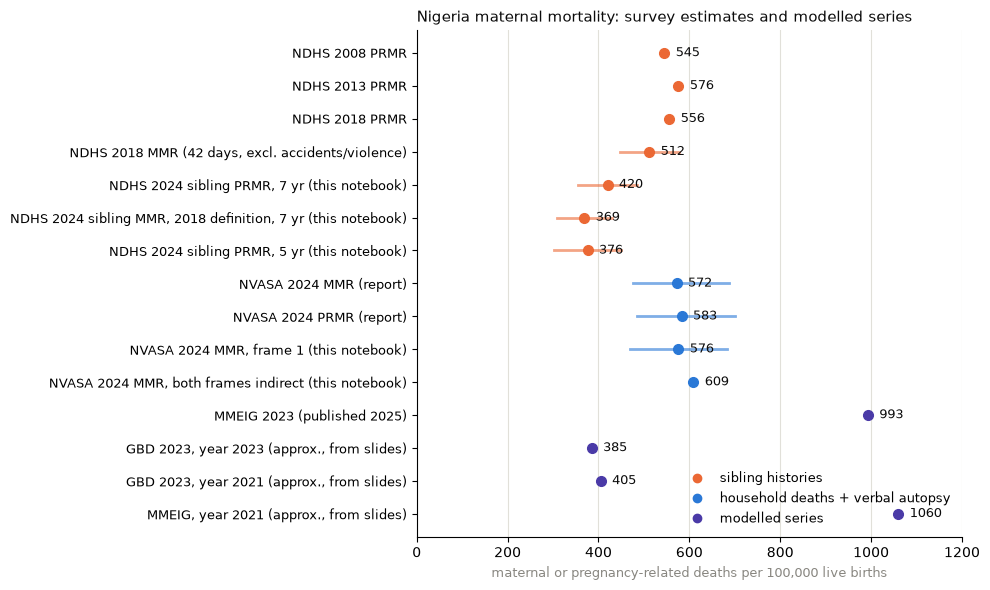

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = {"sibling": ORANGE, "household deaths + VA": BLUE, "household deaths": BLUE, "model": "#4a3aa7"}
p = pub.iloc[::-1].reset_index(drop=True)
for i, r in p.iterrows():
    c = colors[r.method]
    if pd.notna(r.lower):
        ax.plot([r.lower, r.upper], [i, i], color=c, lw=2, alpha=0.6)
    ax.plot(r.ratio, i, "o", color=c, ms=7)
    ax.text(r.ratio + 25, i, f"{r.ratio:.0f}", va="center", fontsize=9, color=INK)
ax.set_yticks(range(len(p))); ax.set_yticklabels(p.estimate_label, fontsize=9)
ax.set_xlabel("maternal or pregnancy-related deaths per 100,000 live births", color=MUTED, fontsize=9)
ax.set_xlim(0, 1200); ax.xaxis.grid(True, color=GRID, linewidth=0.8); ax.yaxis.grid(False)
for s in ["top", "right"]: ax.spines[s].set_visible(False)
for m, c in [("sibling histories", ORANGE), ("household deaths + verbal autopsy", BLUE), ("modelled series", "#4a3aa7")]:
    ax.plot([], [], "o", color=c, label=m)
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.set_title("Nigeria maternal mortality: survey estimates and modelled series", loc="left", fontsize=11, color=INK)
fig.tight_layout(); fig.savefig("fig3_mmr_comparison.png", dpi=150, bbox_inches="tight")

## 9. Reading the results

**The report's number holds up.** Rebuilding exposure from the NDHS household roster and
fertility from the birth histories reproduces the published MMR of 572 (this notebook: 576,
95% CI 469–683) and the all-cause rate of 3.29 per 1,000.

**The screened frame does not change the picture much.** Its maternal share is about three
points higher, which would push an indirect MMR to roughly 600–640, but the report's
reasons for excluding it (no birth denominators, deaths that seem to refer to a wider
population) argue against leaning on it for a level. Its cause distribution is close to
frame 1's: haemorrhage first, then unspecified, abortion-related, indirect, hypertensive,
infection.

**The sibling method, run on the same survey, gives a much lower level.** The 7-year
sibling PRMR is about 420 (355–486) and the MMR on the 2018 definition about 370
(308–430), versus 572–583 from household deaths. The code reproduces every published 2018
sibling figure, so this is not a method artefact. The gap is not specific to maternal
deaths: sibling histories yield an all-cause female mortality rate 15–49 of 2.4 per 1,000
against 3.3 from the household roster, with the shortfall concentrated at ages 40–49. The
2018 NDHS sibling estimate was 3.18 per 1,000, so the 2024 sibling data imply an
implausibly fast decline (about 25% in six years), which points to under-reporting of
sister deaths in 2024 rather than to a real drop.

**Where GBD and MMEIG sit.** The IHME comparison slides show GBD 2023 at roughly 385–405
per 100,000 in 2021–2023 and MMEIG at roughly 990–1,060, with the Das Gupta decomposition
attributing most of the 600-point gap to all-cause mortality and the rest to cause
fraction, births, and scaling. The 2024 survey data split the difference in an informative
way:

- the household-roster all-cause rate (3.3 per 1,000, about 330 per 100,000) matches GBD's
  female 15–49 all-cause level (about 340) and is half MMEIG's custom envelope (about 640);
- the household-death MMR (572) sits well above GBD (about 400) and well below MMEIG
  (about 1,000);
- the sibling estimates (370–420) land on GBD.

So the survey supports GBD's all-cause envelope but suggests GBD's maternal cause fraction
may be low: in the VASA, 27–30% of women's deaths aged 15–49 are maternal, a fraction that,
applied to GBD's own envelope, gives an MMR near 570 rather than 400. Neither survey method
supports an MMR near 1,000.

**Caveats.** Verbal autopsy misclassification cuts both ways (the report notes maternal and
pregnancy-related counts nearly coincide, which is suspicious). Household death rosters
miss women who died away from the household and households that dissolved after a death.
Sibling histories miss deaths of sisters the respondent did not know about and are
age-misreported. Confidence intervals here are jackknife over clusters and do not include
these non-sampling errors.